In [90]:
%matplotlib inline

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage.io as skio
import matplotlib.patches as mpatches
import scipy.stats as stats
from collections import defaultdict
import tqdm
import shap
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNet, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import HuberRegressor, RANSACRegressor
from sklearn.svm import SVR
import joblib

import warnings
warnings.filterwarnings(action='ignore')#,category=sklearn.exceptions.ConvergenceWarning)

In [91]:
def cut_image(img,low=0.2,high=0.8):
    h,w = img.shape[:2]
    return img[int(low*h):int(high*h),int(low*w):int(high*w),:]

def calculate_features(img,percentile_levels=[5,15,25,50,75,85,95],low=0.2,high=0.8):
    features_dict = {}
    for color_chan_id,color in enumerate('RGB'):
        for percentile_level in percentile_levels:
            
            cutted_image = cut_image(img,low=low,high=high)
            feature_value = np.percentile(cutted_image[:,:,color_chan_id].ravel(),percentile_level)
            feature_name = f'{color}_p={percentile_level}'
            
            features_dict[feature_name] = feature_value
    return features_dict

# Classify severity function
def classify_severity(hb):
    if hb < 8.0: return 0  # Severe
    elif hb < 11.0: return 1  # Moderate
    elif hb < 12.0: return 2  # Mild
    else: return 3  # Normal

def explain_model_with_shap(model_name, fitted_pipeline, X_background, X_explain):
    model = fitted_pipeline.named_steps["regressor"]
    scaler = fitted_pipeline.named_steps["scaler"]
    X_explain_scaled = scaler.transform(X_explain)
    X_background_scaled = scaler.transform(X_background)

    if model_name in ["ElasticNet", "Ridge", "Lasso"]:
        explainer = shap.LinearExplainer(model, X_background_scaled)
        shap_values = explainer(X_explain_scaled)
    elif model_name in ["RandomForest", "GradientBoosting"]:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_explain_scaled)
    elif model_name == "SVR":
        explainer = shap.KernelExplainer(model.predict, X_background_scaled)
        shap_values = explainer.shap_values(X_explain_scaled)
    else:
        raise ValueError(f"SHAP explainer not defined for model: {model_name}")
    
    return explainer, shap_values

In [92]:
# DATA_DIR = os.path.expanduser("~/cp-anemia-detection/data/fingernail-anemia")
DATA_DIR = "/Users/romerocruzsa/Workspace/Projects/Research/cp-anemia-detection/data/fingernail-anemia"
CSV_PATH = os.path.join(DATA_DIR, "metadata.csv")
metadata = pd.read_csv(CSV_PATH)

In [93]:
metadata.head()

,PATIENT_ID,MEASUREMENT_DATE,HB_LEVEL_GperL,NAIL_BOUNDING_BOXES,SKIN_BOUNDING_BOXES
0,1,14b0293a34344cc4fba0fa39d5370c52,134.0,"[[251, 447, 302, 505], [123, 429, 183, 483], [...","[[267, 586, 324, 627], [148, 556, 200, 614], [..."
1,2,14b0293a34344cc4fba0fa39d5370c52,108.0,"[[236, 503, 281, 556], [148, 457, 195, 514], [...","[[252, 612, 294, 647], [162, 585, 212, 632], [..."
2,5,14b0293a34344cc4fba0fa39d5370c52,84.0,"[[244, 508, 277, 562], [183, 448, 220, 505], [...","[[264, 629, 303, 662], [193, 584, 232, 619], [..."
3,6,14b0293a34344cc4fba0fa39d5370c52,138.0,"[[311, 456, 363, 521], [182, 408, 237, 471], [...","[[318, 609, 380, 650], [189, 562, 245, 616], [..."
4,7,14b0293a34344cc4fba0fa39d5370c52,119.0,"[[29, 513, 78, 556], [119, 435, 165, 479], [18...","[[29, 635, 79, 678], [117, 564, 175, 615], [20..."


In [94]:
metadata["HB_LEVEL_GperDeciL"] = metadata["HB_LEVEL_GperL"]/10
metadata.sample(5) 

,PATIENT_ID,MEASUREMENT_DATE,HB_LEVEL_GperL,NAIL_BOUNDING_BOXES,SKIN_BOUNDING_BOXES,HB_LEVEL_GperDeciL
212,294,1466220e41f866b2da3159d8201d7e2e,153.0,"[[99, 493, 145, 561], [156, 417, 221, 489], [2...","[[73, 616, 139, 651], [160, 575, 228, 643], [2...",15.3
10,16,7239c14d8ddc5b692aeae707b0f99ecc,137.0,"[[280, 537, 317, 590], [223, 460, 264, 529], [...","[[268, 634, 300, 675], [205, 597, 242, 647], [...",13.7
136,191,4ef4b8d96f66ffb5109cd2ad8fb95915,151.0,"[[331, 595, 396, 677], [223, 528, 292, 601], [...","[[343, 749, 411, 800], [229, 681, 295, 795], [...",15.1
115,163,dd5cba527a3cc1ac054c5645a2e84435,103.0,"[[321, 594, 359, 652], [246, 517, 294, 581], [...","[[311, 720, 355, 775], [219, 666, 274, 720], [...",10.3
4,7,14b0293a34344cc4fba0fa39d5370c52,119.0,"[[29, 513, 78, 556], [119, 435, 165, 479], [18...","[[29, 635, 79, 678], [117, 564, 175, 615], [20...",11.9


In [95]:
metadata['NAIL_BOUNDING_BOXES'] = metadata['NAIL_BOUNDING_BOXES'].apply(json.loads)
metadata['SKIN_BOUNDING_BOXES'] = metadata['SKIN_BOUNDING_BOXES'].apply(json.loads)

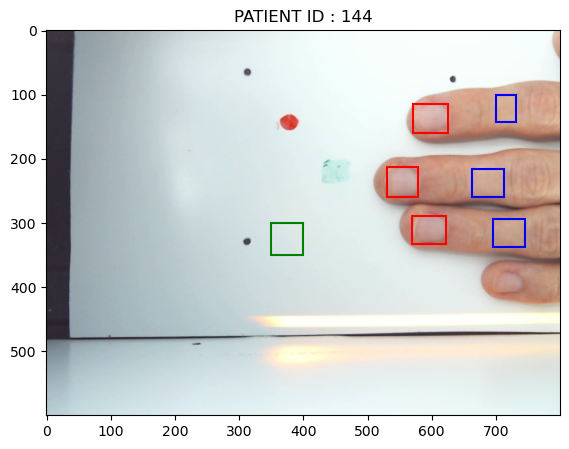

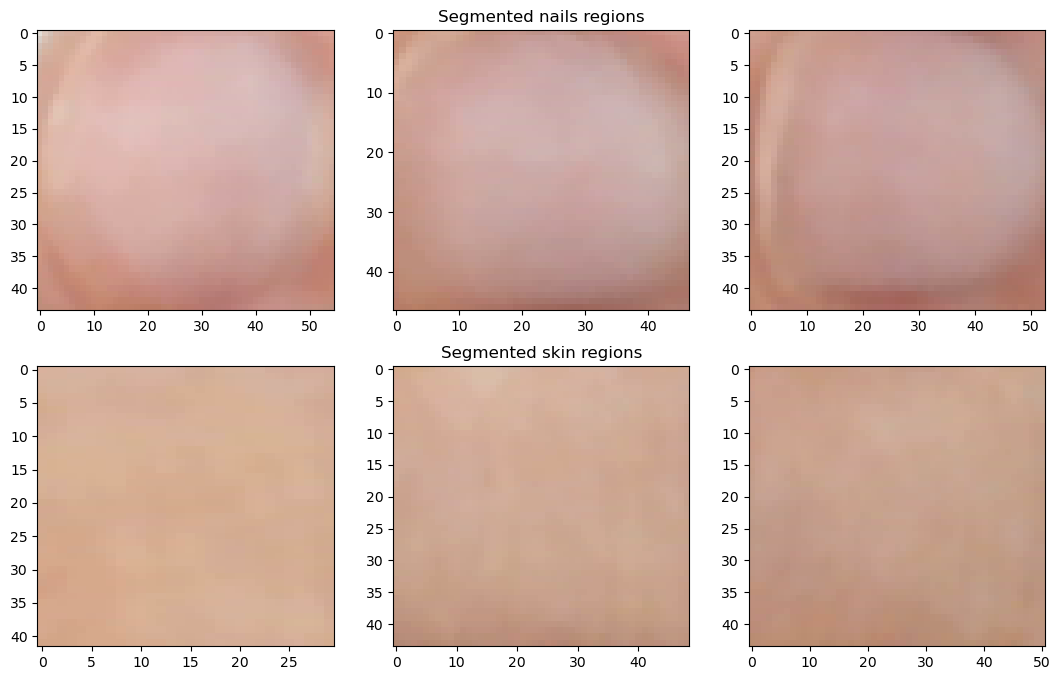

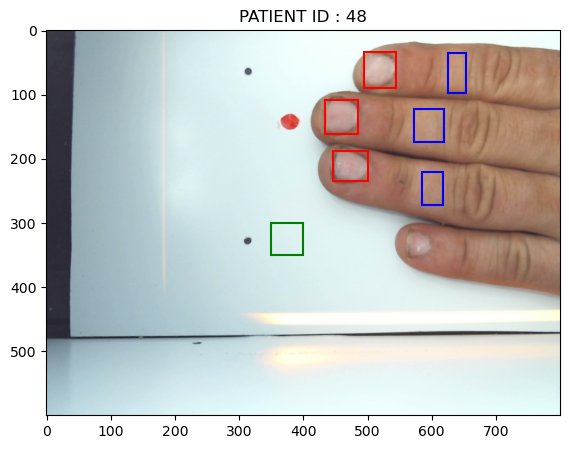

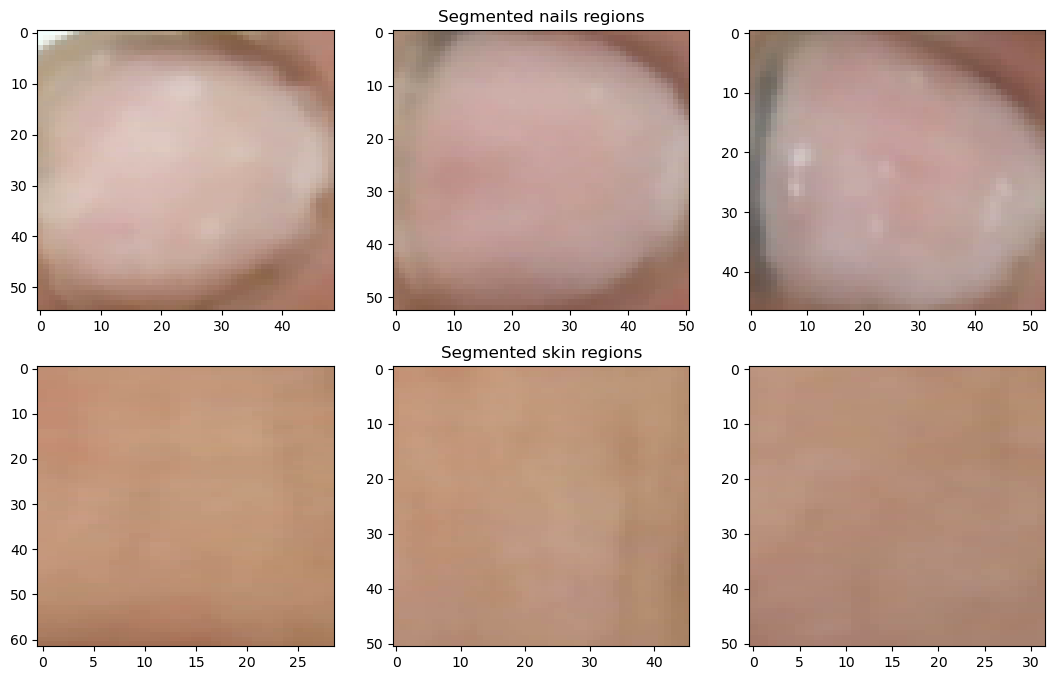

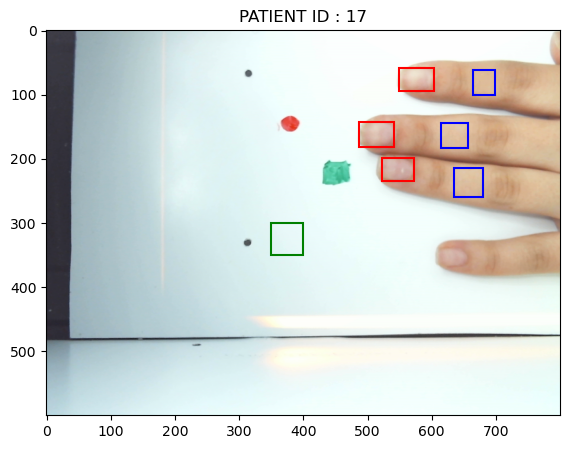

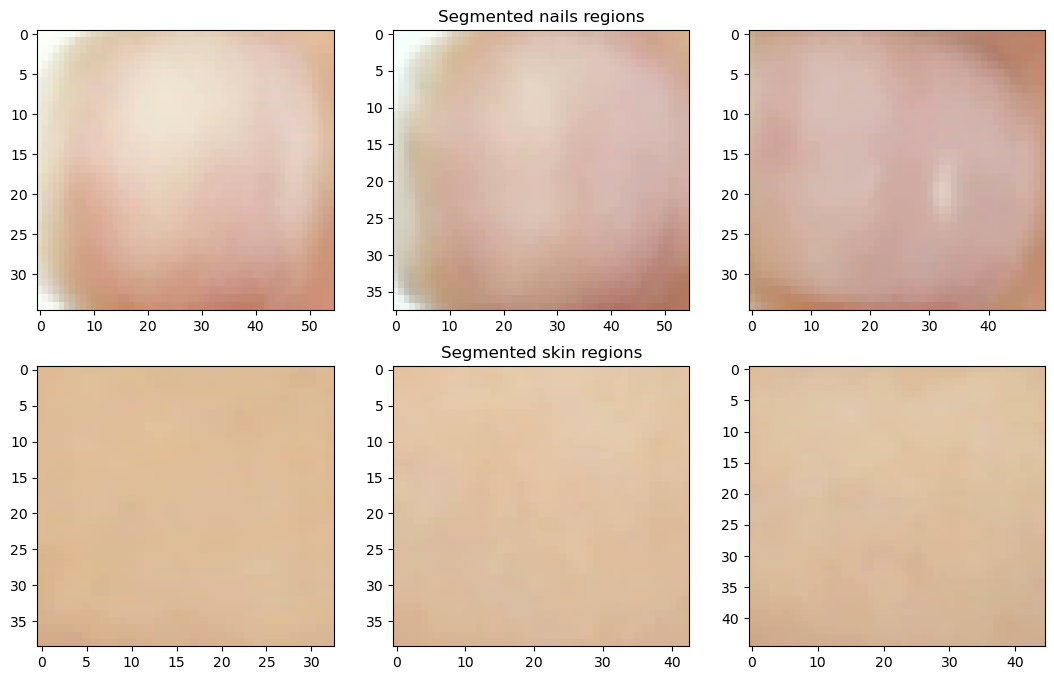

In [96]:
image_folder = 'data/photo/'
N_MAX_IMAGES = 3

for j,(_, row) in enumerate(metadata.sample(N_MAX_IMAGES).iterrows()):
    
    if j ==  N_MAX_IMAGES:
        break
    
    label = 'Anemic' if row.HB_LEVEL_GperDeciL < 12.0 else 'Non-anemic'
    img_path = os.path.join(DATA_DIR ,label, f'{row.PATIENT_ID}.jpg')
    
    img = skio.imread(img_path)
    
    plt.figure(figsize=(7,5))
    plt.imshow(img)
    
    nails_bboxes = row.NAIL_BOUNDING_BOXES
    skin_bboxes  = row.SKIN_BOUNDING_BOXES
    
    ax = plt.gca()
    
    for _color,_bboxes in zip(['r','b'],[nails_bboxes,skin_bboxes]):
        for top,left,bot,right in _bboxes:
            
            w,h = right-left,bot-top
            
            rectangle = mpatches.Rectangle(xy=(left,top),width=w,height=h,fill=None,
                                           color=_color,linewidth=1.5)
            
            ax.add_patch(rectangle)
            
    white_region_rectangle = mpatches.Rectangle(xy=(350,300),width=50,height=50,fill=None,
                                           color='green',linewidth=1.5)
    ax.add_patch(white_region_rectangle)
    
    plt.title(f"PATIENT ID : {row.PATIENT_ID}")
    
    fig,axs = plt.subplots(2,3,figsize=(13,8))
    axs = axs.ravel()
    
    all_bboxes = nails_bboxes + skin_bboxes
    
    for i,(top,left,bot,right) in enumerate(all_bboxes):
        axs[i].imshow(img[top:bot,left:right],aspect='auto')
        if i == 1:
            axs[i].set_title("Segmented nails regions")
        if i == 4:
            axs[i].set_title("Segmented skin regions")
        
    plt.show()

In [97]:
# import numpy as np
# from skimage.io import imread
# import cv2
# import pandas as pd
# import matplotlib.pyplot as plt

# def compute_normalized_rgb_from_reference_region_fixed(nail_images, original_image, ref_box_size=(50, 50)):
#     height, width, _ = original_image.shape
#     box_h, box_w = ref_box_size
#     ref_region = original_image[height - box_h:height, 0:box_w]
#     white_ref_median = {
#         color: np.median(ref_region[:, :, chan].ravel())
#         for chan, color in enumerate("RGB")
#     }
#     feature_dict = {}
#     for i, img in enumerate(nail_images[:3]):
#         for chan, color in enumerate("RGB"):
#             mean_val = np.mean(img[:, :, chan])
#             norm_val = mean_val / white_ref_median[color]
#             feature_dict[f'NAIL_{i+1}_{color}_mean'] = norm_val
#     return pd.DataFrame([feature_dict])

# def select_three_nails_with_least_background(cropped_images, background_threshold=240, background_ratio_cutoff=0.7):
#     background_ratios = []
#     for img in cropped_images:
#         gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
#         white_pixels = np.sum(gray > background_threshold)
#         total_pixels = gray.size
#         background_ratio = white_pixels / total_pixels
#         background_ratios.append(background_ratio)
#     sorted_indices = sorted(range(len(cropped_images)), key=lambda i: background_ratios[i])
#     filtered_indices = [i for i in sorted_indices if background_ratios[i] < background_ratio_cutoff]
#     selected_images = [cropped_images[i] for i in filtered_indices[:3]]
#     return selected_images

# def segment_hand_and_detect_clean_fingernails(image):
#     hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
#     lower_skin = np.array([0, 20, 70], dtype=np.uint8)
#     upper_skin = np.array([20, 255, 255], dtype=np.uint8)
#     skin_mask = cv2.inRange(hsv, lower_skin, upper_skin)

#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
#     skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
#     skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_OPEN, kernel, iterations=2)

#     contours, _ = cv2.findContours(skin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     largest_contour = max(contours, key=cv2.contourArea)
#     largest_mask = np.zeros_like(skin_mask)
#     cv2.drawContours(largest_mask, [largest_contour], -1, 255, thickness=-1)

#     hand_segmented = np.full_like(image, 255)
#     hand_only = cv2.bitwise_and(image, image, mask=largest_mask)
#     for c in range(3):
#         hand_segmented[:, :, c] = np.where(largest_mask == 255, hand_only[:, :, c], 255)

#     epsilon = 0.01 * cv2.arcLength(largest_contour, True)
#     approx = cv2.approxPolyDP(largest_contour, epsilon, True)
#     hull = cv2.convexHull(approx, returnPoints=False)
#     defects = cv2.convexityDefects(approx, hull)

#     def euclidean_dist(p1, p2):
#         return np.linalg.norm(np.array(p1) - np.array(p2))

#     fingertips = []
#     if defects is not None:
#         for i in range(defects.shape[0]):
#             s, e, _, d = defects[i, 0]
#             if d > 1000:
#                 fingertips.extend([tuple(approx[s][0]), tuple(approx[e][0])])

#     clustered_fingertips = []
#     for pt in fingertips:
#         if all(euclidean_dist(pt, c) > 10 for c in clustered_fingertips):
#             clustered_fingertips.append(pt)

#     M = cv2.moments(largest_contour)
#     cx, cy = (int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])) if M["m00"] else (0, 0)

#     img_h, img_w = image.shape[:2]
#     box_width = int(img_w * 0.10)
#     box_height = int(img_h * 0.10)
#     shift_distance = int(min(img_w, img_h) * 0.05)
#     raw_bboxes = []
#     for pt in clustered_fingertips:
#         direction = np.array([cx - pt[0], cy - pt[1]])
#         norm = np.linalg.norm(direction)
#         if norm != 0:
#             direction = direction / norm
#         center = (pt[0] + int(direction[0] * shift_distance), pt[1] + int(direction[1] * shift_distance))
#         top_left = (center[0] - box_width // 2, center[1] - box_height // 2)
#         bottom_right = (center[0] + box_width // 2, center[1] + box_height // 2)
#         raw_bboxes.append((top_left, bottom_right))

#     def merge_close_boxes(bboxes, threshold=int(img_w * 0.10)):
#         merged = []
#         used = [False] * len(bboxes)
#         for i, box_a in enumerate(bboxes):
#             if used[i]:
#                 continue
#             (x1a, y1a), (x2a, y2a) = box_a
#             acc = [x1a, y1a, x2a, y2a]
#             count = 1
#             used[i] = True
#             for j, box_b in enumerate(bboxes[i+1:], start=i+1):
#                 if used[j]:
#                     continue
#                 if euclidean_dist(box_a[0], box_b[0]) < threshold:
#                     x1b, y1b = box_b[0]
#                     x2b, y2b = box_b[1]
#                     acc = [acc[k] + val for k, val in enumerate([x1b, y1b, x2b, y2b])]
#                     count += 1
#                     used[j] = True
#             acc = tuple(int(v / count) for v in acc)
#             merged.append(((acc[0], acc[1]), (acc[2], acc[3])))
#         return merged

#     final_bboxes = merge_close_boxes(raw_bboxes)

#     # Optional visualization (can be toggled off for batch processing)
#     final_image = hand_segmented.copy()
#     for top_left, bottom_right in final_bboxes:
#         cv2.rectangle(final_image, top_left, bottom_right, (255, 0, 0), 2)

#     return final_bboxes

# def crop_bounding_boxes(image, bounding_boxes):
#     cropped_images = []
#     for (top_left, bottom_right) in bounding_boxes:
#         x1, y1 = top_left
#         x2, y2 = bottom_right
#         cropped = image[y1:y2, x1:x2]
#         cropped_images.append(cropped)
#     return cropped_images

# # ✅ Full pipeline example
# # image = imread("your_image_path.jpg")
# # bboxes = segment_hand_and_detect_clean_fingernails(image)
# # cropped_nails = crop_bounding_boxes(image, bboxes)
# # best_nails = select_three_nails_with_least_background(cropped_nails)
# # features = compute_normalized_rgb_from_reference_region_fixed(best_nails, image)


In [98]:
# # image = imread("your_image_path.jpg")
# # bboxes = segment_hand_and_detect_clean_fingernails(image)
# # cropped_nails = crop_bounding_boxes(image, bboxes)
# # best_nails = select_three_nails_with_least_background(cropped_nails)
# # features = compute_normalized_rgb_from_reference_region_fixed(best_nails, image)
# # 
# path = "/Users/romerocruzsa/Workspace/Projects/Research/cp-anemia-detection/backend/test_sample2.png"
# image = skio.imread(path)
# bboxes = segment_hand_and_detect_clean_fingernails(image)
# cropped_nails = crop_bounding_boxes(image, bboxes)
# best_nails = select_three_nails_with_least_background(cropped_nails)
# features = compute_normalized_rgb_from_reference_region_fixed(best_nails, image)
# display(features)

In [99]:
images = defaultdict(list)

for j, (_, row) in tqdm.tqdm(enumerate(metadata.iterrows())):
    label = 'Anemic' if row.HB_LEVEL_GperDeciL < 12.0 else 'Non-anemic'
    img_path = os.path.join(DATA_DIR ,label, f'{row.PATIENT_ID}.jpg')
    img = skio.imread(img_path)

    nails_bboxes = row.NAIL_BOUNDING_BOXES
    skin_bboxes = row.SKIN_BOUNDING_BOXES

    # ➕ Load NAIL crops
    for finger_num, (top, left, bot, right) in enumerate(nails_bboxes, start=1):
        key = f'NAIL_{finger_num}'
        images[key].append(img[top:bot, left:right])

    # # ➕ Load SKIN crops
    # for patch_num, (top, left, bot, right) in enumerate(skin_bboxes, start=1):
    #     key = f'SKIN_{patch_num}'
    #     images[key].append(img[top:bot, left:right])

    # ➕ White reference region (still using hardcoded region)
    images['WHITE_REF'].append(img[350:400, 300:350])

250it [00:02, 121.06it/s]


In [100]:
# # Compute white reference medians
# white_ref_median = pd.DataFrame({
#     f'{color}': [np.median(img[:, :, chan].ravel()) for img in images['WHITE_REF']] 
#     for chan, color in enumerate("RGB")
# })

# # Compute mean RGB for each nail and normalize
# mean_rgb_per_nail = []

# for i in range(1, 4):  # Assuming 3 nails per patient
#     key = f'NAIL_{i}'
#     channel_means = []

#     for idx, img in enumerate(images[key]):
#         mean_values = {f'{key}_{color}_mean': np.mean(img[:, :, chan]) / white_ref_median[color].iloc[idx]
#                        for chan, color in enumerate("RGB")}
#         channel_means.append(mean_values)

#     mean_rgb_per_nail.append(pd.DataFrame(channel_means))

# # Combine all nails' mean RGB features into one DataFrame
# features = pd.concat(mean_rgb_per_nail, axis=1)

# # Optionally average across nails per patient
# # features = features.groupby(features.index).mean()

# Step 1: Compute white reference medians
white_ref_median = pd.DataFrame({
    f'{color}': [np.median(img[:, :, chan].ravel()) for img in images['WHITE_REF']]
    for chan, color in enumerate("RGB")
})

# Step 2: Compute normalized RGB features for each nail
mean_rgb_per_nail = []
for i in range(1, 4):  # Assuming 3 nails per patient
    key = f'NAIL_{i}'
    channel_means = []
    for idx, img in enumerate(images[key]):
        mean_values = {
            f'{key}_{color}_mean': np.mean(img[:, :, chan]) / white_ref_median[color].iloc[idx]
            for chan, color in enumerate("RGB")
        }
        channel_means.append(mean_values)
    mean_rgb_per_nail.append(pd.DataFrame(channel_means))

# Step 3: Compute normalized RGB features for each skin patch
mean_rgb_per_skin = []
for i in range(1, 4):  # Assuming 3 nails per patient
    key = f'SKIN_{i}'
    channel_means = []
    for idx, img in enumerate(images[key]):
        mean_values = {
            f'{key}_{color}_mean': np.mean(img[:, :, chan]) / white_ref_median[color].iloc[idx]
            for chan, color in enumerate("RGB")
        }
        channel_means.append(mean_values)
    mean_rgb_per_skin.append(pd.DataFrame(channel_means))


# Step 4: Combine everything into one final DataFrame
features = pd.concat(mean_rgb_per_nail + mean_rgb_per_skin, axis=1)

In [101]:
# cols = features_df.columns[:-3]
# features = features_df[cols]
# target = features_df['HB_LEVEL_GperDeciL']

target = metadata['HB_LEVEL_GperDeciL']

0.276 	 0.44


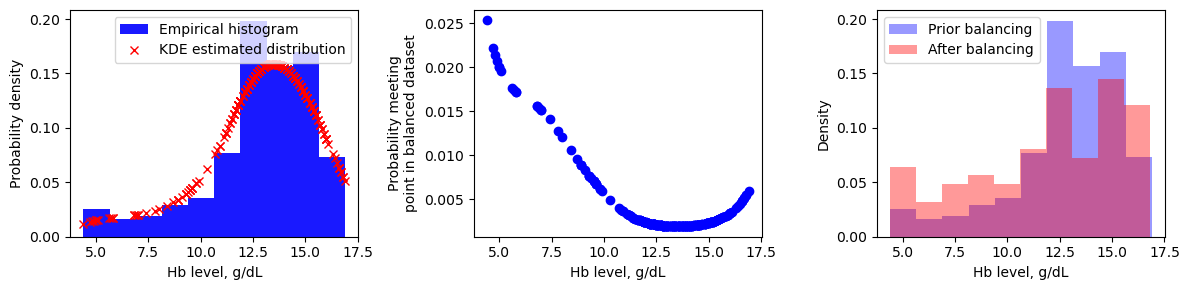

In [102]:
np.random.seed(42)

target_kde = stats.gaussian_kde(target,bw_method=0.5)(target)
weights = 1/target_kde
weights /= np.sum(weights)

patient_ids = metadata['PATIENT_ID']
balanced_patient_ids = np.random.choice(patient_ids,size=100,replace=False,p=weights)
balancing_mask = metadata['PATIENT_ID'].isin(balanced_patient_ids).values
np.mean(target < 12.0)
np.mean(target[balancing_mask] < 12.0)

print(f"{np.mean(target < 12.0)} \t {np.mean(target[balancing_mask] < 12.0)}")

plt.figure(figsize=(12,3))
plt.subplot(1,3,1)

plt.hist(target,density=True,label='Empirical histogram',color='b',alpha=0.9)
plt.plot(target,target_kde,'x',color='r',label='KDE estimated distribution')

plt.legend()
plt.ylabel("Probability density")
plt.xlabel("Hb level, g/dL")

plt.subplot(1,3,2)
plt.plot(target,weights,'o',color='b')

plt.ylabel("Probability meeting\npoint in balanced dataset")
plt.xlabel("Hb level, g/dL")

plt.subplot(1,3,3)
plt.hist(target,density=True,alpha=0.4,label='Prior balancing',color='b')
plt.hist(target[balancing_mask],density=True,alpha=0.4,label='After balancing',color='r')

plt.xlabel("Hb level, g/dL")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

X = features[balancing_mask]
y = target[balancing_mask]

In [103]:
features

,NAIL_1_R_mean,NAIL_1_G_mean,NAIL_1_B_mean,NAIL_2_R_mean,NAIL_2_G_mean,NAIL_2_B_mean,NAIL_3_R_mean,NAIL_3_G_mean,NAIL_3_B_mean
0,0.918853,0.749793,0.688297,0.964720,0.798425,0.755486,0.976110,0.791642,0.754632
1,0.939447,0.696036,0.633254,0.964539,0.716145,0.660571,1.003972,0.742637,0.693302
2,0.980905,0.784081,0.736569,0.989235,0.808146,0.769058,1.016016,0.821366,0.775971
3,0.856078,0.667431,0.594504,0.891266,0.688663,0.630335,0.961414,0.729553,0.679977
4,0.954041,0.740425,0.701125,0.896554,0.703216,0.669118,0.863628,0.667656,0.632999
...,...,...,...,...,...,...,...,...,...
245,0.886900,0.692089,0.648249,0.875059,0.693534,0.657401,0.881685,0.690736,0.658415
246,0.847456,0.639896,0.610502,0.878796,0.694090,0.666536,0.901448,0.679803,0.654288
247,0.885959,0.652501,0.598912,0.941530,0.734255,0.690136,1.010119,0.781354,0.740724
248,0.934682,0.696808,0.594120,0.941175,0.743707,0.665225,0.982978,0.792780,0.706418


Fitting 7 folds for each of 50 candidates, totalling 350 fits


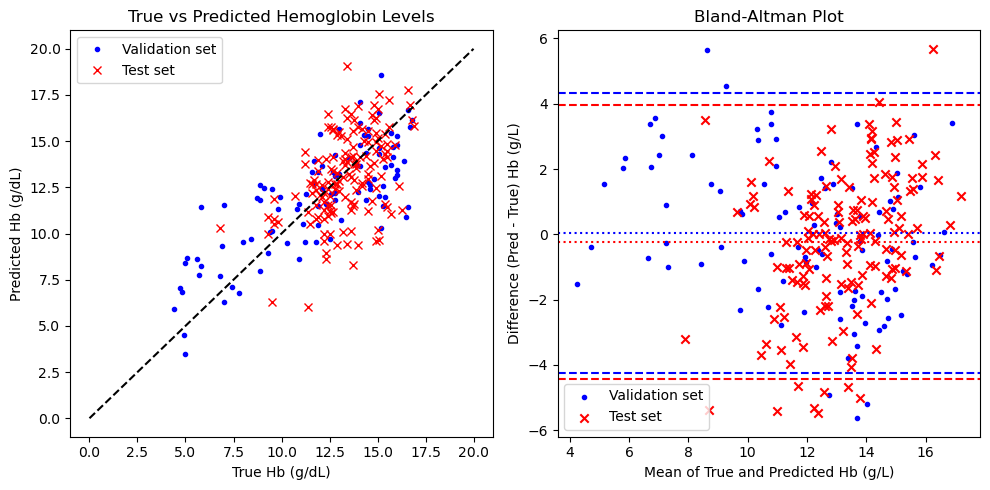

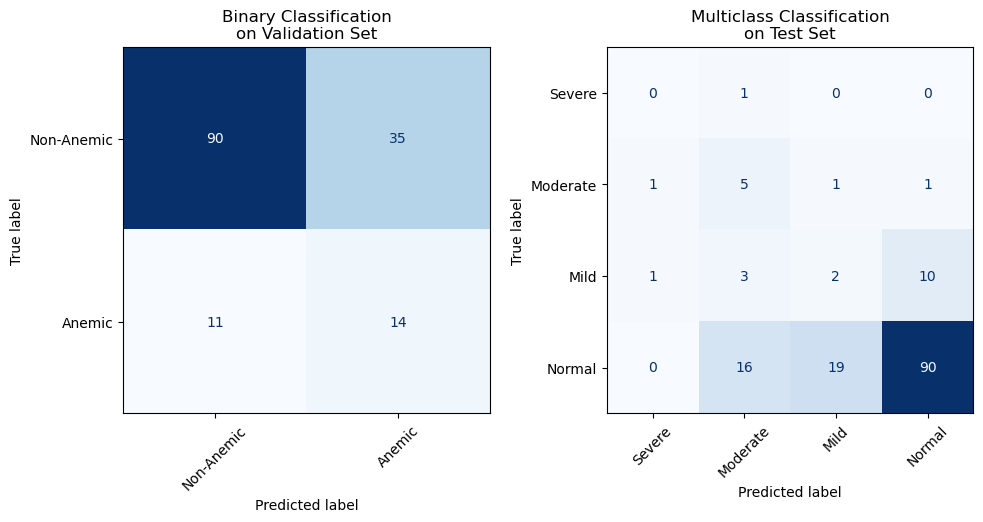

Fitting 7 folds for each of 10 candidates, totalling 70 fits


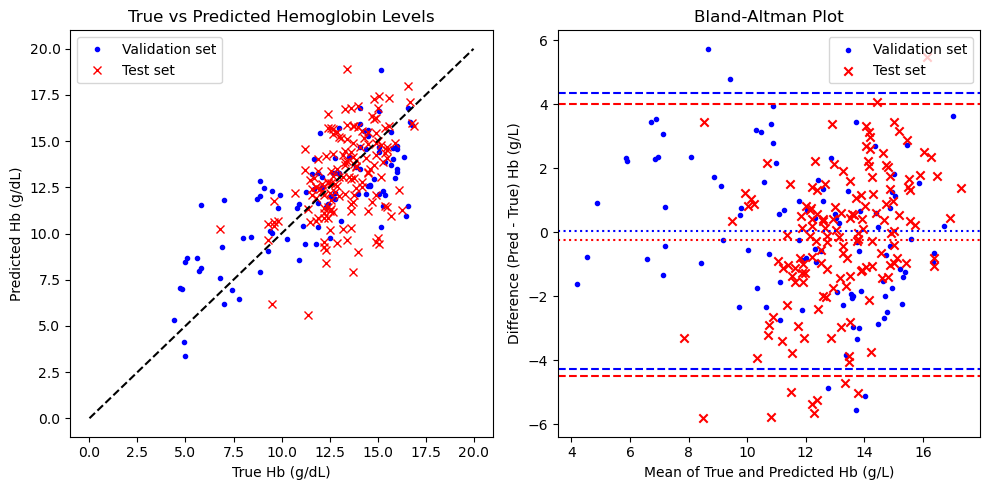

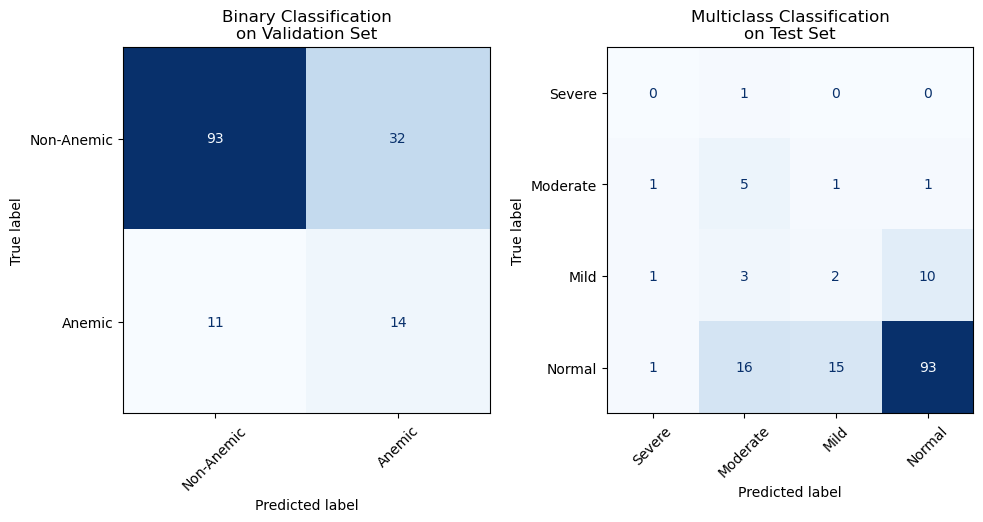

Fitting 7 folds for each of 10 candidates, totalling 70 fits


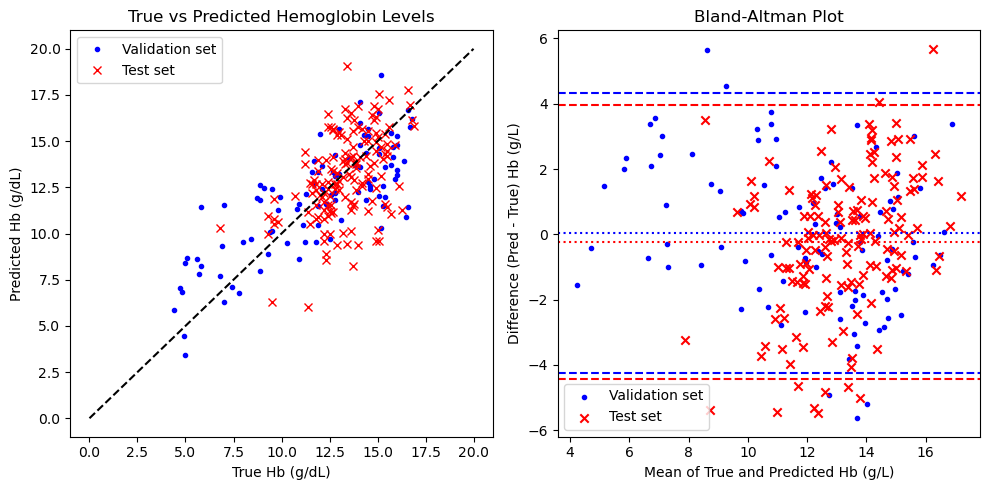

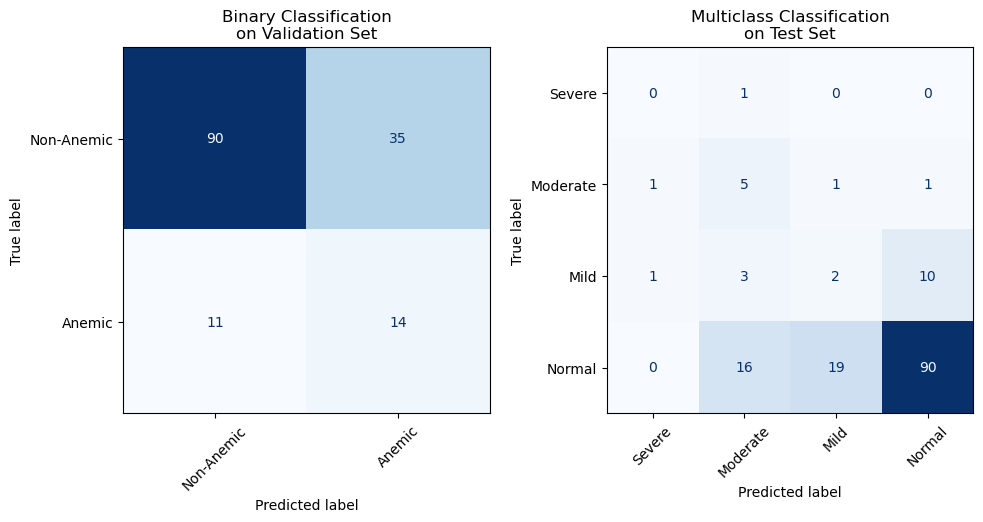

Fitting 7 folds for each of 4 candidates, totalling 28 fits


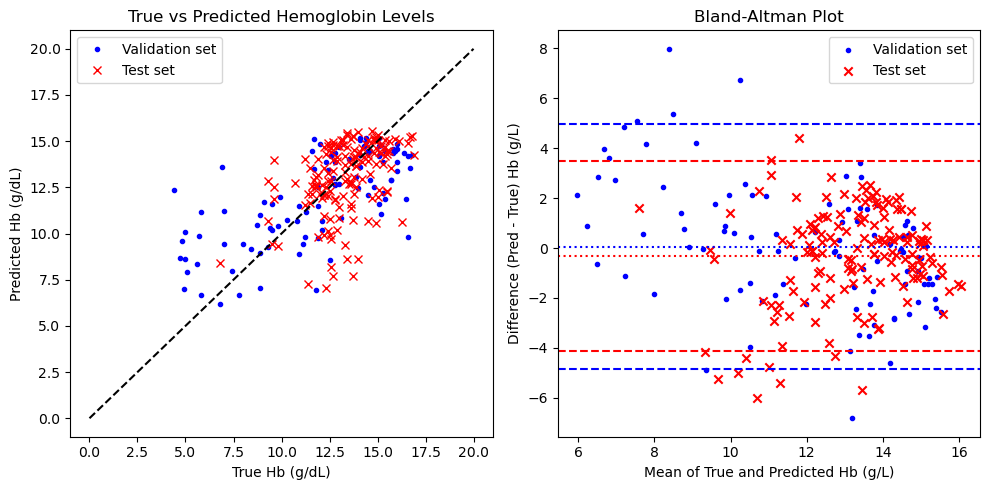

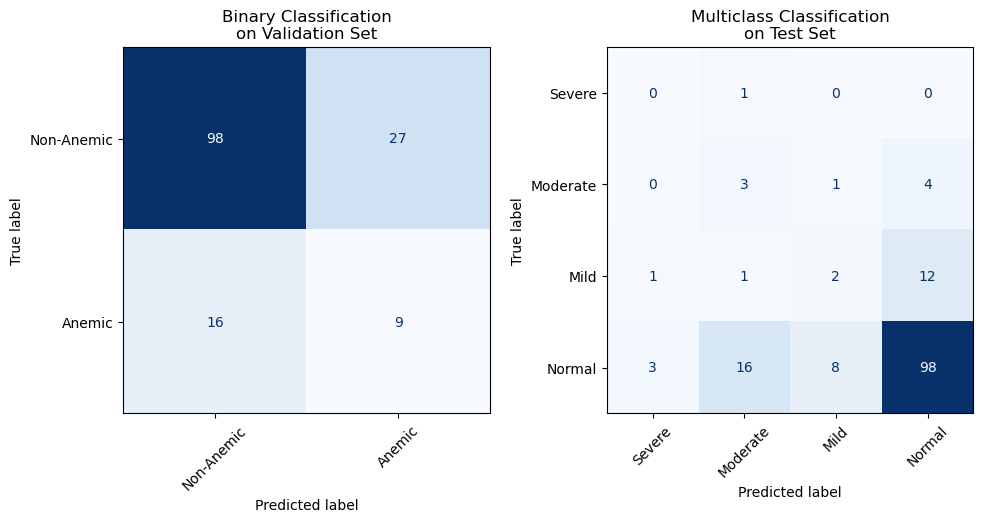

Fitting 7 folds for each of 4 candidates, totalling 28 fits


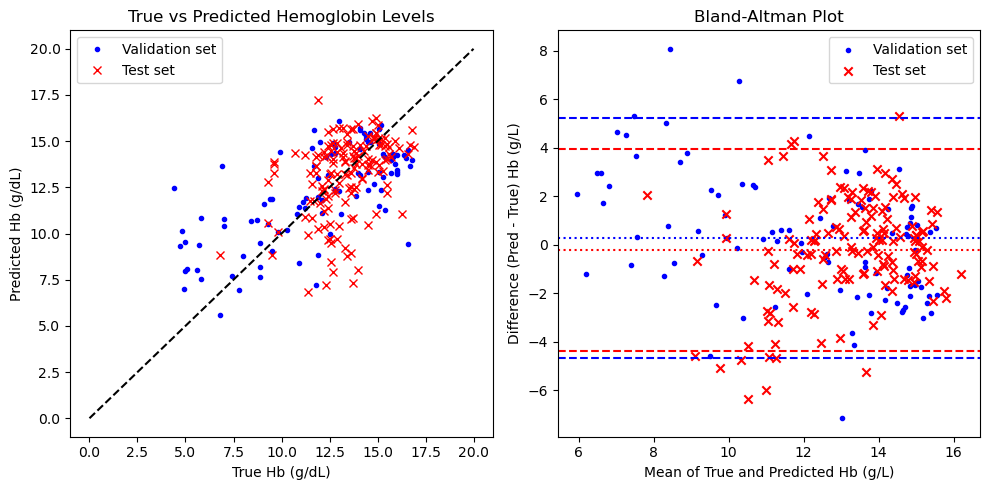

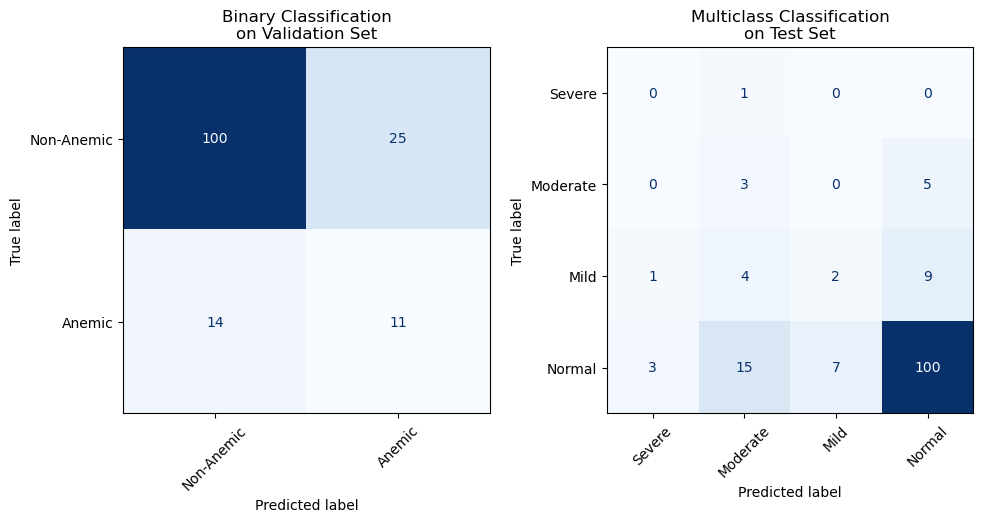

Fitting 7 folds for each of 6 candidates, totalling 42 fits


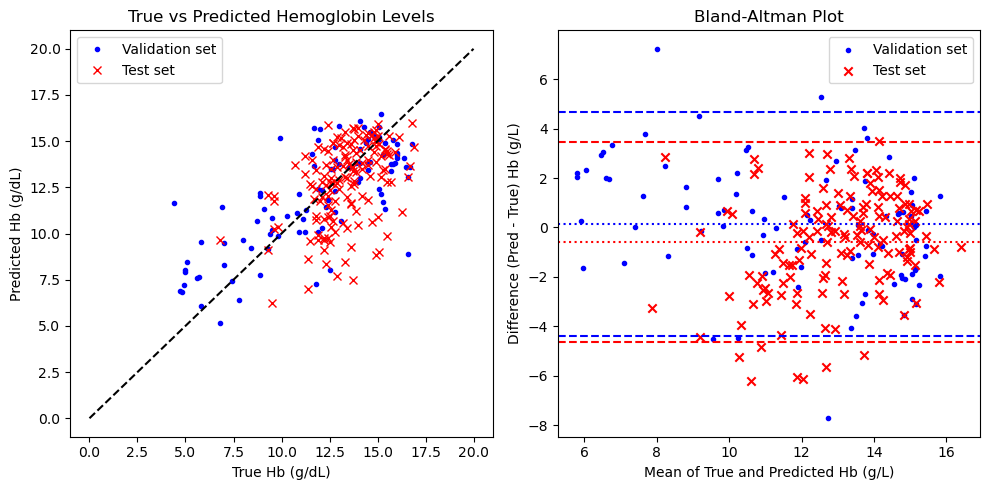

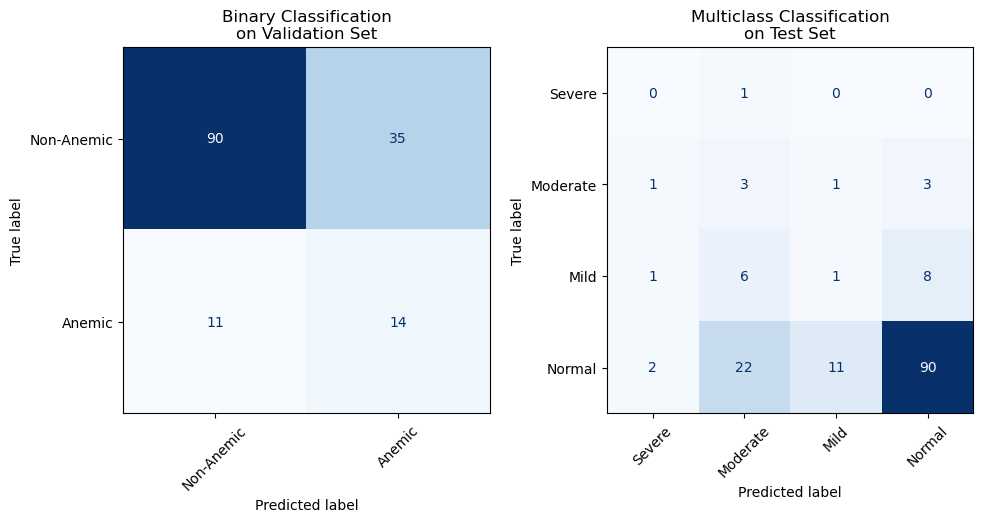

Fitting 7 folds for each of 2 candidates, totalling 14 fits


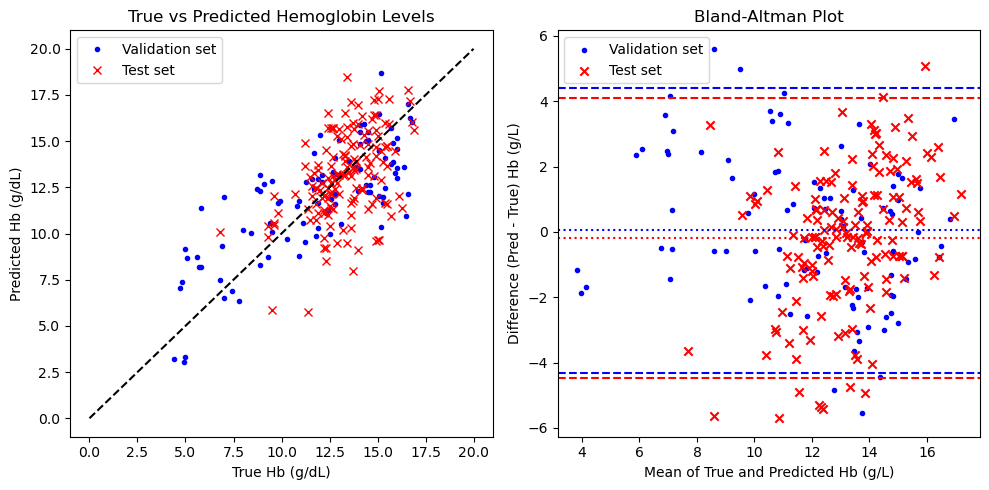

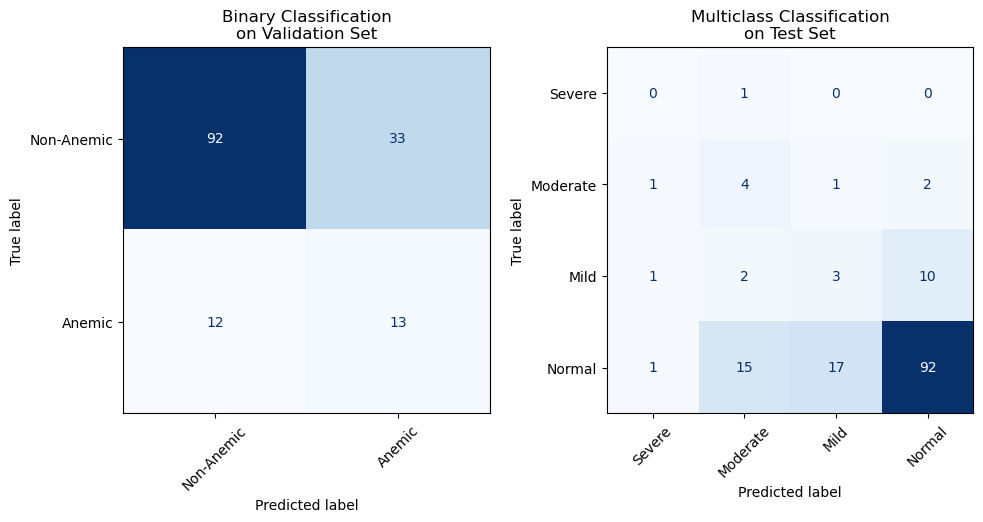

Fitting 7 folds for each of 2 candidates, totalling 14 fits


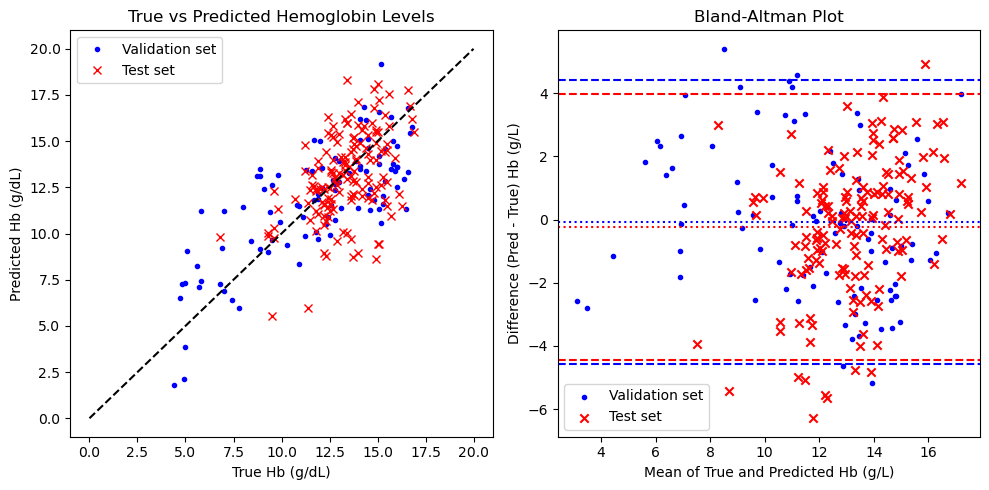

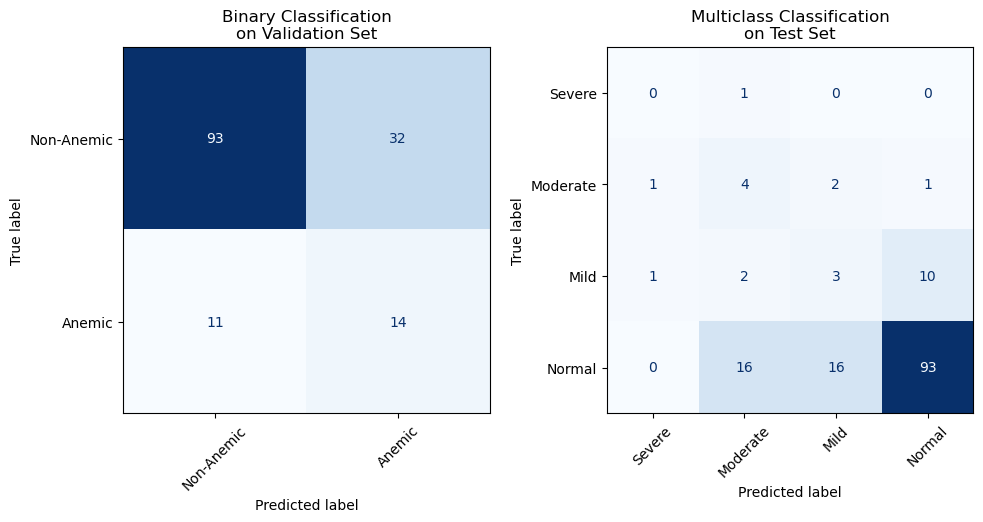

In [104]:
X = features[balancing_mask]
y = target[balancing_mask]

X_test = features[~balancing_mask]
y_test = target[~balancing_mask]

cv_scheme = KFold(n_splits=7)
scoring = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

models = {
    "ElasticNet": ElasticNet(max_iter=10000),
    "Ridge": Ridge(max_iter=10000),
    "Lasso": Lasso(max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "SupportVectorRegression": SVR(),
    "HuberRegressor": HuberRegressor(),
    "RANSACRegressor": RANSACRegressor()
}

param_grids = {
    "ElasticNet": {'regressor__l1_ratio': [0.01, 0.1, 0.5, 0.9, 0.99],
                   'regressor__alpha': np.logspace(-4, 4, num=10)}, 
    "Ridge": {'regressor__alpha': np.logspace(-4, 4, num=10)},
    "Lasso": {'regressor__alpha': np.logspace(-4, 4, num=10)},
    "RandomForest": {'regressor__n_estimators': [50, 100],
                     'regressor__max_depth': [5, 10]},
    "GradientBoosting": {'regressor__n_estimators': [50, 100],
                         'regressor__learning_rate': [0.01, 0.1]},
    "SupportVectorRegression": {'regressor__C': [0.1, 1, 10],
                                'regressor__epsilon': [0.1, 0.2]},
    "HuberRegressor": {'regressor__epsilon': [1.1, 1.35]},
    "RANSACRegressor": {'regressor__min_samples': [0.5, 0.75]}
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('regressor', model)
    ])
    grid = GridSearchCV(pipeline, param_grids[name], cv=cv_scheme, scoring=scoring, return_train_score=True, verbose=1)
    grid.fit(X, y)
    best_model = grid.best_estimator_
    y_pred_val = cross_val_predict(best_model, X, y, cv=cv_scheme)
    best_model.fit(X, y)
    y_pred_test = best_model.predict(X_test)
    val_mae = mean_absolute_error(y, y_pred_val)
    val_mse = mean_squared_error(y, y_pred_val, squared=True)
    val_rmse = mean_squared_error(y, y_pred_val, squared=False)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_mse = mean_squared_error(y_test, y_pred_test, squared=True)
    test_rmse = mean_squared_error(y_test, y_pred_test, squared=False)

    # Bland-Altman and scatter plot
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Plot 1: True vs Predicted
    axs[0].plot(y, y_pred_val, 'b.', label='Validation set')
    axs[0].plot(y_test, y_pred_test, 'rx', label='Test set')
    axs[0].plot([0,20], [0,20], 'k--')
    axs[0].set_title("True vs Predicted Hemoglobin Levels")
    axs[0].set_xlabel("True Hb (g/dL)")
    axs[0].set_ylabel("Predicted Hb (g/dL)")
    axs[0].legend()

    # Plot 2: Bland-Altman
    sets = [[y, y_pred_val, 'Validation set'], [y_test, y_pred_test, 'Test set']]
    colors = {'Validation set': 'b', 'Test set': 'r'}
    markers = {'Validation set': '.', 'Test set': 'x'}

    for _true, _pred, _label in sets:
        _avg = (_true + _pred) / 2
        _diff = _pred - _true
        _bias = np.mean(_diff)
        _SD = np.std(_diff)
        
        axs[1].scatter(_avg, _diff, label=_label, color=colors[_label], marker=markers[_label])
        axs[1].axhline(_bias, color=colors[_label], linestyle='dotted')
        axs[1].axhline(_bias + 1.96*_SD, color=colors[_label], linestyle='dashed')
        axs[1].axhline(_bias - 1.96*_SD, color=colors[_label], linestyle='dashed')

    axs[1].set_title("Bland-Altman Plot")
    axs[1].set_xlabel("Mean of True and Predicted Hb (g/L)")
    axs[1].set_ylabel("Difference (Pred - True) Hb (g/L)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Binary classification
    true_labels = y_test < 12.0
    pred_labels = y_pred_test < 12.0

    true_severity = np.array([classify_severity(h) for h in y_test])
    pred_severity = np.array([classify_severity(h) for h in y_pred_test])

    # Compute confusion matrices [ [TN, FP], [FN, TP] ]
    binary_cm = confusion_matrix(true_labels, pred_labels)
    tn, fp, fn, tp = binary_cm.ravel()
    sensitivity = tp / (tp + fn)  # Recall or True Positive Rate
    specificity = tn / (tn + fp)
    # print(f"Binary Classification: \nSensitivity (Recall, Anemia detection): {sensitivity:.2f} \t Specificity (Normal Hb detection): {specificity:.2f}")

    multiclass_cm = confusion_matrix(true_severity, pred_severity)
    multiclass_labels = ["Severe", "Moderate", "Mild", "Normal"]
    # import pdb;pdb.set_trace()
    sensitivity_list = []
    specificity_list = []

    for i in range(len(multiclass_labels)):
        TP = multiclass_cm[i, i]
        FN = np.sum(multiclass_cm[i, :]) - TP
        FP = np.sum(multiclass_cm[:, i]) - TP
        TN = np.sum(multiclass_cm) - (TP + FP + FN)

        sen = TP / (TP + FN) if (TP + FN) > 0 else 0
        spe = TN / (TN + FP) if (TN + FP) > 0 else 0
        sensitivity_list.append(sen)
        specificity_list.append(spe)

    # # Display per class
    # print("Class-wise Sensitivity (Recall):")
    # for i, sen in enumerate(sensitivity_list):
    #     print(f"{multiclass_labels[i]}: {sen:.2f}")

    # print("\nClass-wise Specificity:")
    # for i, spe in enumerate(specificity_list):
    #     print(f"{multiclass_labels[i]}: {spe:.2f}")

    # Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Binary CM
    ConfusionMatrixDisplay(binary_cm, display_labels=["Non-Anemic", "Anemic"]).plot(ax=axs[0], cmap="Blues", colorbar=False)
    axs[0].set_title("Binary Classification\non Validation Set")
    axs[0].tick_params(axis='x', rotation=45)

    # Multiclass CM
    ConfusionMatrixDisplay(multiclass_cm, display_labels=multiclass_labels).plot(ax=axs[1], cmap="Blues", colorbar=False)
    axs[1].set_title("Multiclass Classification\non Test Set")
    axs[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    model = best_model.named_steps["regressor"]
    scaler = best_model.named_steps["scaler"]
    X_explain_scaled = scaler.transform(X[:100])
    X_background_scaled = scaler.transform(X)

    # if name in ["Random Forest", "Gradient Boosting"]:
    #     explainer = shap.TreeExplainer(model)  # model = fitted RandomForest or GradientBoosting
    #     shap_values = explainer.shap_values(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"feat. {i}" for i in range(X.shape[1])], max_display=10)

    # elif name == "Support Vector Regression":
    #     explainer = shap.KernelExplainer(model.predict, shap.sample(X_background_scaled, 100))
    #     shap_values = explainer.shap_values(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"f{i}" for i in range(X.shape[1])], max_display=10)

    # else:
    #     explainer = shap.LinearExplainer(model, X_background_scaled)
    #     shap_values = explainer(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"f{i}" for i in range(X.shape[1])], max_display=10)

    path = f"/Users/romerocruzsa/Workspace/Projects/Research/cp-anemia-detection/weights/best_{name.lower()}_model.pkl"
    joblib.dump(best_model, path)
    
    results.append((name, sensitivity, specificity, sensitivity_list, specificity_list, 
                    val_mae, val_mse, val_rmse, test_mae, test_mse, test_rmse))

In [105]:
results_df = pd.DataFrame(results, columns=["Model", "Senstivity (Binary)", "Specificity (Binary)",
                                             "Sensitivity (Multiclass)", "Specificity (Multiclass)",
                                             "Validation MAE", "Validation MSE", "Validation RMSE",
                                             "Test MAE", "Test MSE", "Test RMSE"])
import ace_tools_open as tools; tools.display_dataframe_to_user(name="Model Comparison: Hemoglobin Regression", dataframe=results_df)

Model Comparison: Hemoglobin Regression


0.276 	 0.750


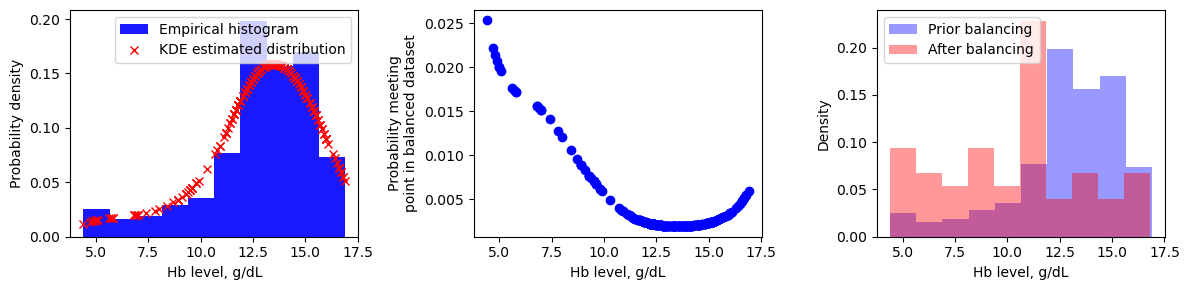

In [54]:
# Add severity class to metadata
metadata["SEVERITY"] = [classify_severity(hb) for hb in target]

# KDE balancing within each severity class
balanced_ids = []
samples_per_class = 15  # ~12-13 samples from each of 4 classes for ~50 total

for severity_class in range(4):
    class_mask = metadata["SEVERITY"] == severity_class
    class_targets = target[class_mask]
    class_ids = metadata.loc[class_mask, "PATIENT_ID"].values
    
    if len(class_ids) < samples_per_class:
        continue  # Avoid sampling more than available
    
    class_kde = stats.gaussian_kde(class_targets, bw_method=0.5)(class_targets)
    class_weights = 1 / class_kde
    class_weights /= class_weights.sum()
    
    sampled_ids = np.random.choice(class_ids, size=samples_per_class, replace=False, p=class_weights)
    balanced_ids.extend(sampled_ids)

# Final balanced mask
balanced_patient_ids = np.array(balanced_ids)
balancing_mask = metadata["PATIENT_ID"].isin(balanced_patient_ids).values

# Visualization
plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
target_kde = stats.gaussian_kde(target, bw_method=0.5)(target)
plt.hist(target, density=True, label='Empirical histogram', color='b', alpha=0.9)
plt.plot(target, target_kde, 'x', color='r', label='KDE estimated distribution')
plt.legend()
plt.ylabel("Probability density")
plt.xlabel("Hb level, g/dL")

plt.subplot(1, 3, 2)
weights = 1 / target_kde
weights /= np.sum(weights)
plt.plot(target, weights, 'o', color='b')
plt.ylabel("Probability meeting\npoint in balanced dataset")
plt.xlabel("Hb level, g/dL")

plt.subplot(1, 3, 3)
plt.hist(target, density=True, alpha=0.4, label='Prior balancing', color='b')
plt.hist(target[balancing_mask], density=True, alpha=0.4, label='After balancing', color='r')
plt.xlabel("Hb level, g/dL")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

# Show anemia class balance before/after
print(f"{np.mean(target < 12.0):.3f} \t {np.mean(target[balancing_mask] < 12.0):.3f}")

# Final balanced data
X = features[balancing_mask]
y = target[balancing_mask]

Fitting 7 folds for each of 50 candidates, totalling 350 fits


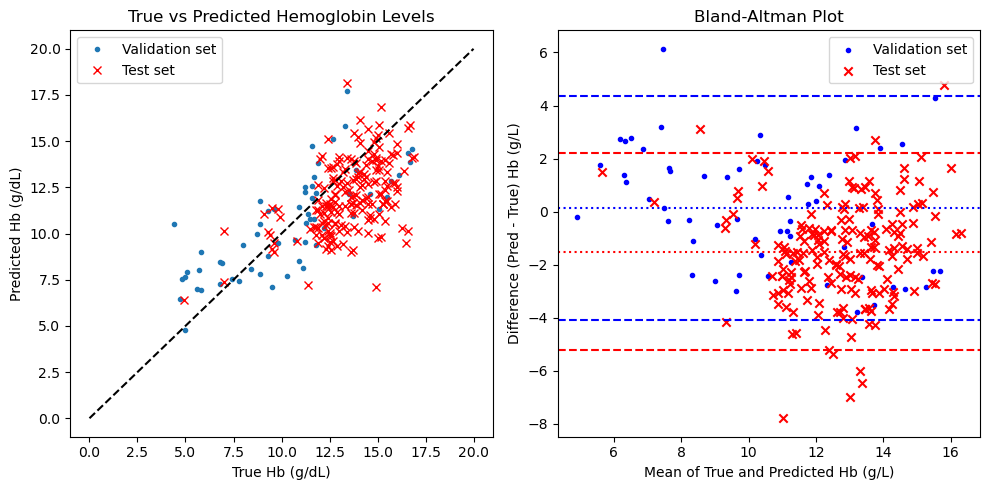

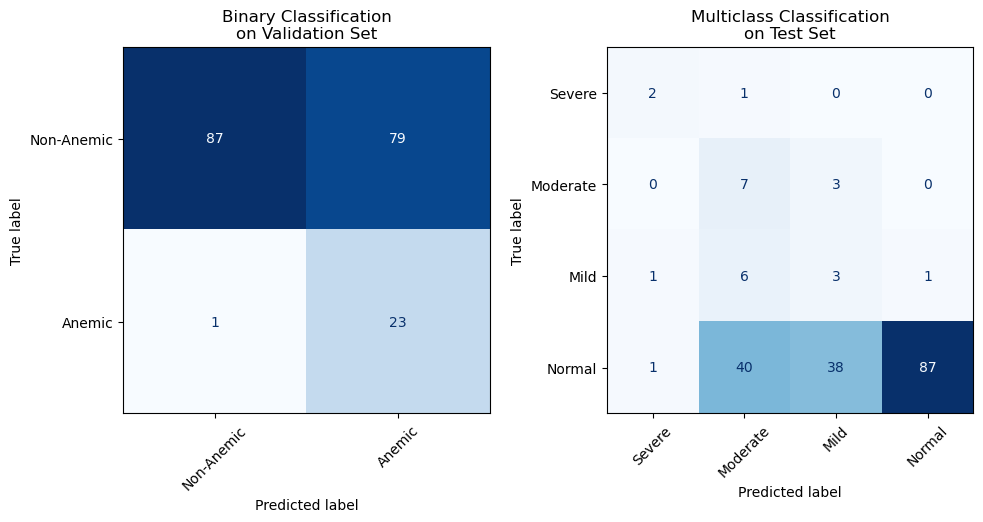

Fitting 7 folds for each of 10 candidates, totalling 70 fits


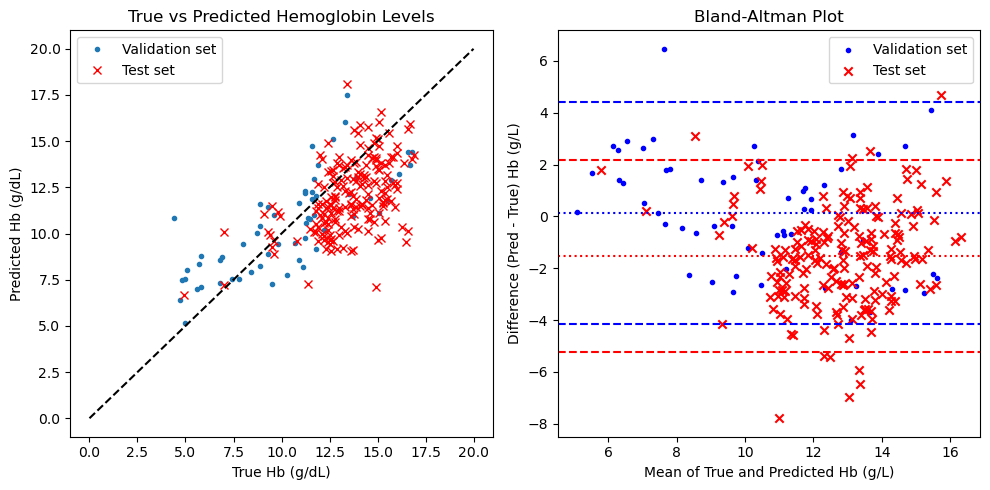

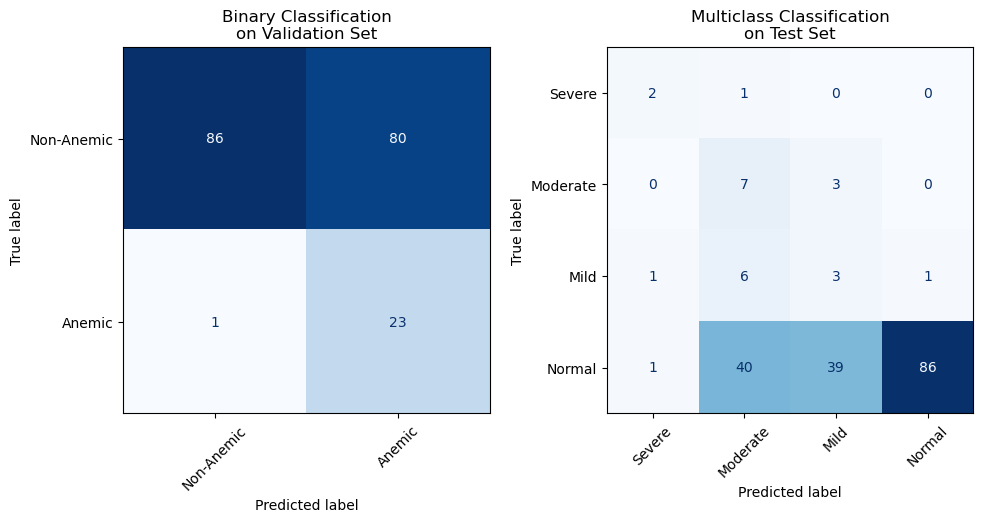

Fitting 7 folds for each of 10 candidates, totalling 70 fits


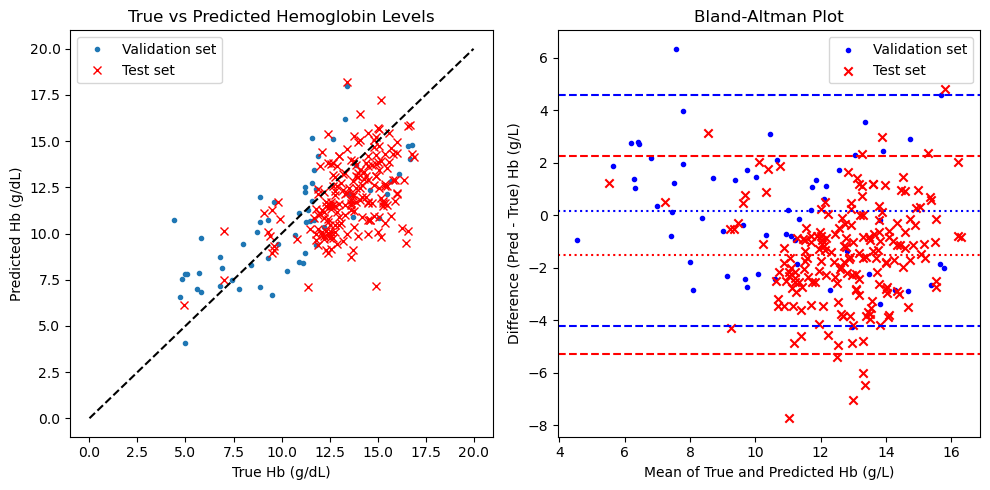

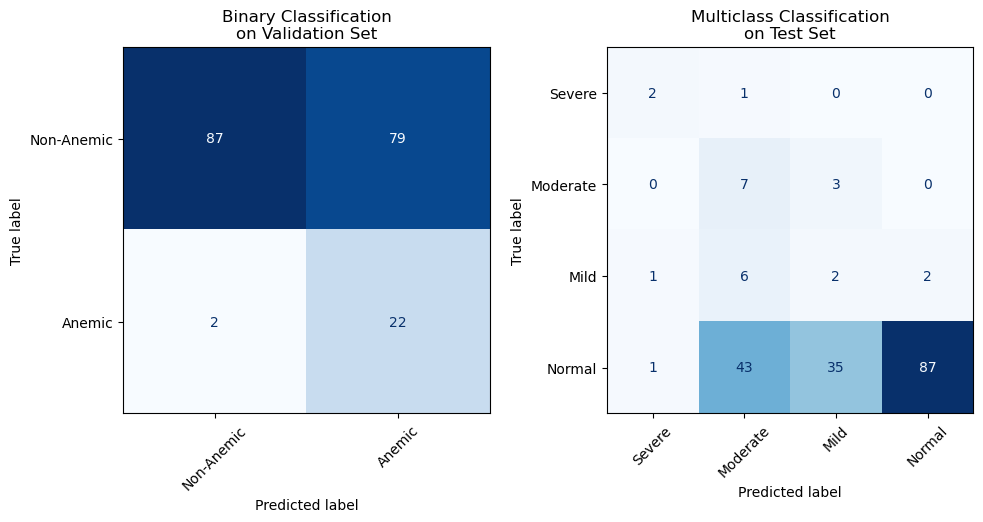

Fitting 7 folds for each of 4 candidates, totalling 28 fits


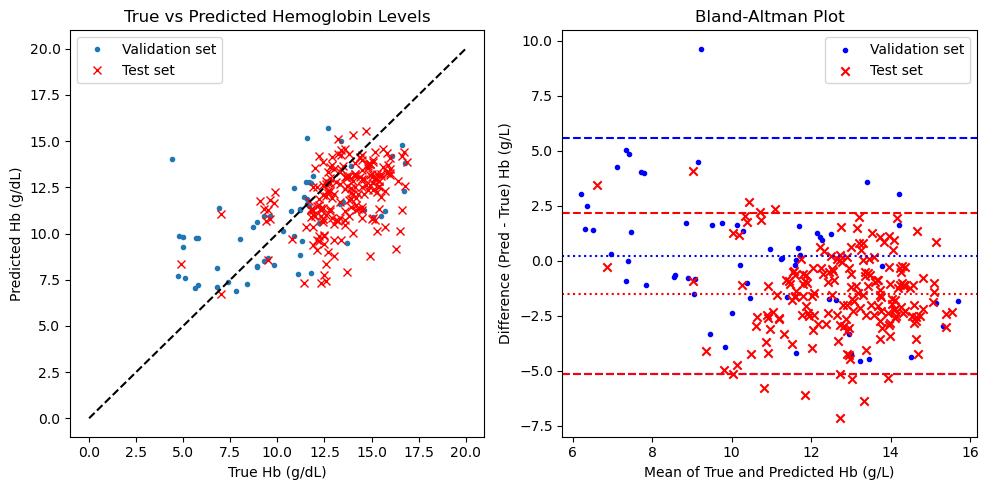

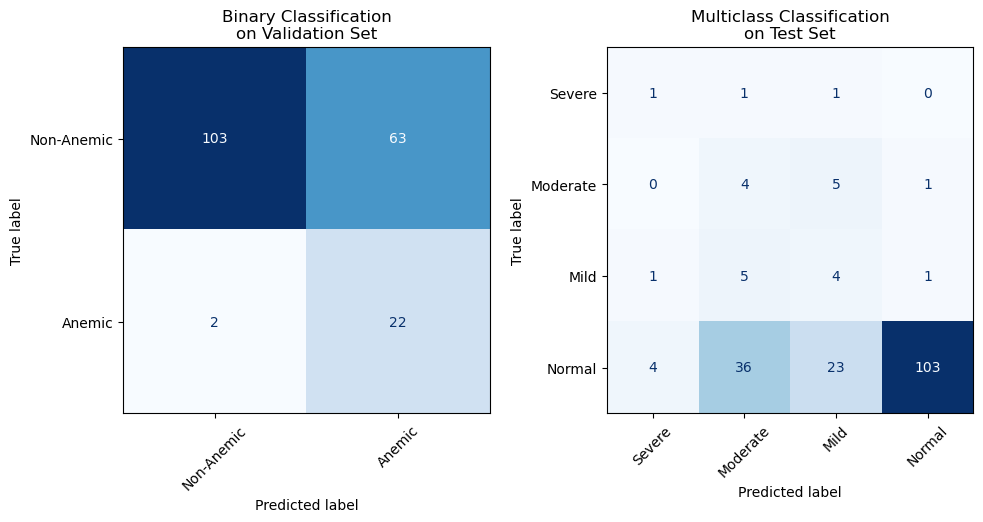

Fitting 7 folds for each of 4 candidates, totalling 28 fits


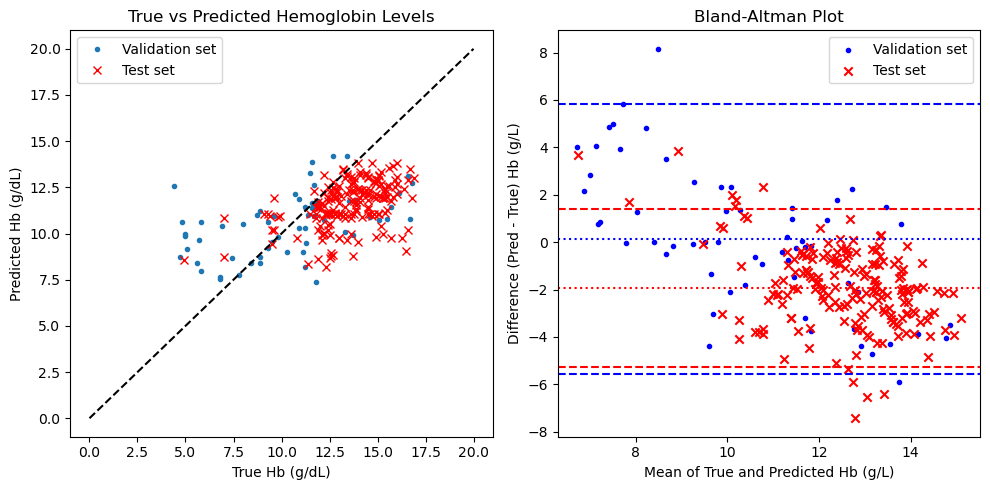

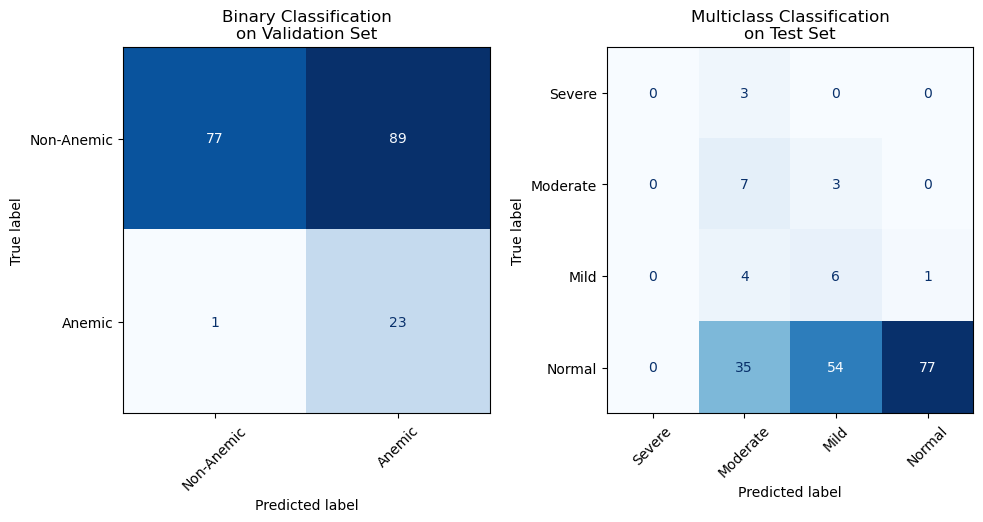

Fitting 7 folds for each of 6 candidates, totalling 42 fits


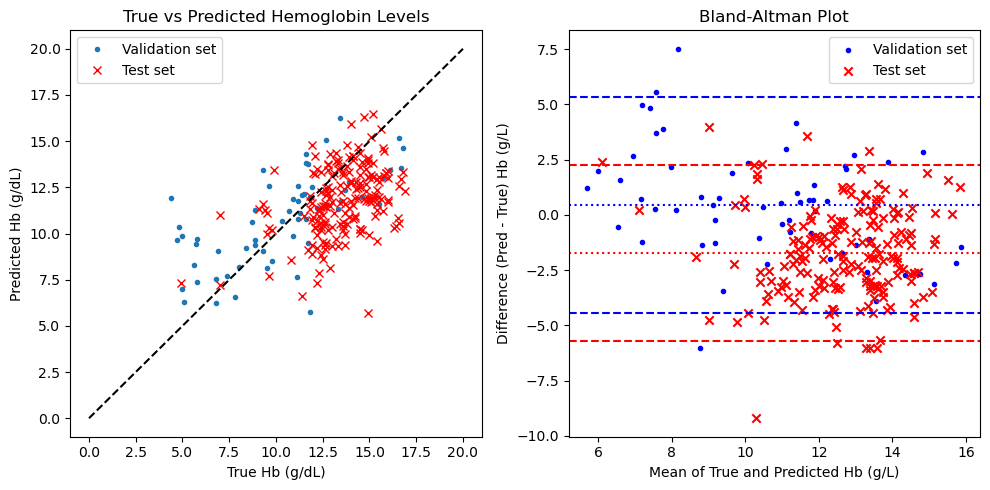

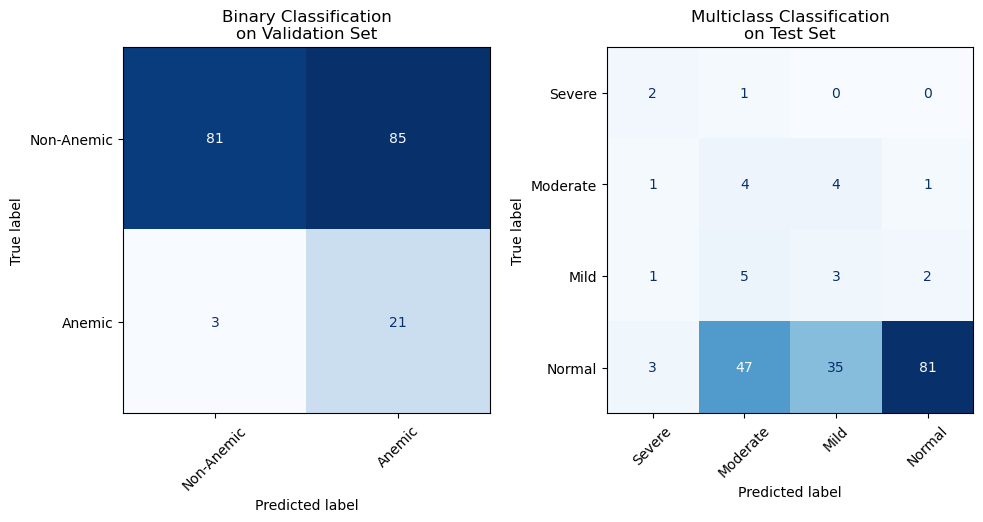

Fitting 7 folds for each of 2 candidates, totalling 14 fits


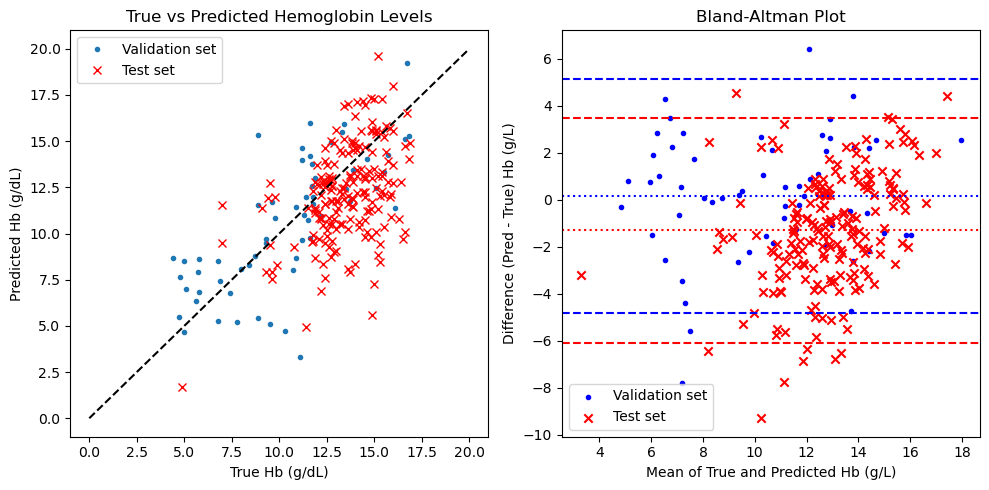

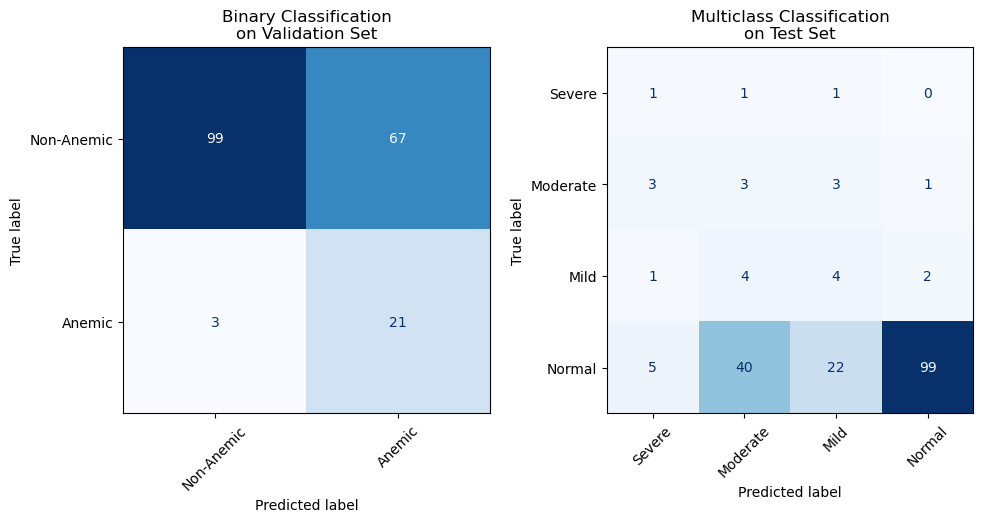

Fitting 7 folds for each of 2 candidates, totalling 14 fits


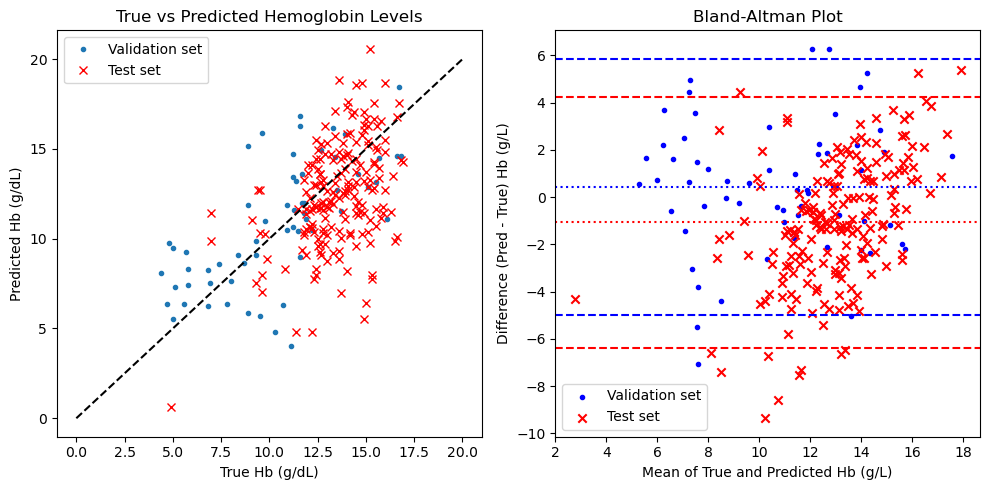

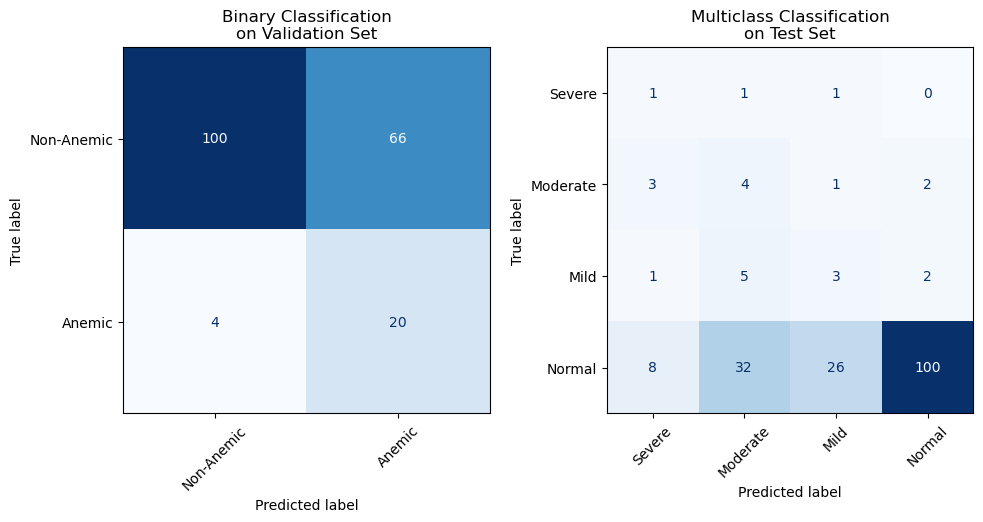

In [55]:
X = features[balancing_mask]
y = target[balancing_mask]

X_test = features[~balancing_mask]
y_test = target[~balancing_mask]

cv_scheme = KFold(n_splits=7)
scoring = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

models = {
    "ElasticNet": ElasticNet(max_iter=10000),
    "Ridge": Ridge(max_iter=10000),
    "Lasso": Lasso(max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "SupportVectorRegression": SVR(),
    "HuberRegressor": HuberRegressor(),
    "RANSACRegressor": RANSACRegressor()
}

param_grids = {
    "ElasticNet": {'regressor__l1_ratio': [0.01, 0.1, 0.5, 0.9, 0.99],
                   'regressor__alpha': np.logspace(-4, 4, num=10)}, 
    "Ridge": {'regressor__alpha': np.logspace(-4, 4, num=10)},
    "Lasso": {'regressor__alpha': np.logspace(-4, 4, num=10)},
    "RandomForest": {'regressor__n_estimators': [50, 100],
                     'regressor__max_depth': [5, 10]},
    "GradientBoosting": {'regressor__n_estimators': [50, 100],
                         'regressor__learning_rate': [0.01, 0.1]},
    "SupportVectorRegression": {'regressor__C': [0.1, 1, 10],
                                'regressor__epsilon': [0.1, 0.2]},
    "HuberRegressor": {'regressor__epsilon': [1.1, 1.35]},
    "RANSACRegressor": {'regressor__min_samples': [0.5, 0.75]}
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('regressor', model)
    ])
    grid = GridSearchCV(pipeline, param_grids[name], cv=cv_scheme, scoring=scoring, return_train_score=True, verbose=1)
    grid.fit(X, y)
    best_model = grid.best_estimator_
    y_pred_val = cross_val_predict(best_model, X, y, cv=cv_scheme)
    best_model.fit(X, y)
    y_pred_test = best_model.predict(X_test)
    val_mae = mean_absolute_error(y, y_pred_val)
    val_mse = mean_squared_error(y, y_pred_val, squared=True)
    val_rmse = mean_squared_error(y, y_pred_val, squared=False)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_mse = mean_squared_error(y_test, y_pred_test, squared=True)
    test_rmse = mean_squared_error(y_test, y_pred_test, squared=False)

    # Bland-Altman and scatter plot
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Plot 1: True vs Predicted
    axs[0].plot(y, y_pred_val, '.', label='Validation set')
    axs[0].plot(y_test, y_pred_test, 'rx', label='Test set')
    axs[0].plot([0,20], [0,20], 'k--')
    axs[0].set_title("True vs Predicted Hemoglobin Levels")
    axs[0].set_xlabel("True Hb (g/dL)")
    axs[0].set_ylabel("Predicted Hb (g/dL)")
    axs[0].legend()

    # Plot 2: Bland-Altman
    sets = [[y, y_pred_val, 'Validation set'], [y_test, y_pred_test, 'Test set']]
    colors = {'Validation set': 'b', 'Test set': 'r'}
    markers = {'Validation set': '.', 'Test set': 'x'}

    for _true, _pred, _label in sets:
        _avg = (_true + _pred) / 2
        _diff = _pred - _true
        _bias = np.mean(_diff)
        _SD = np.std(_diff)
        
        axs[1].scatter(_avg, _diff, label=_label, color=colors[_label], marker=markers[_label])
        axs[1].axhline(_bias, color=colors[_label], linestyle='dotted')
        axs[1].axhline(_bias + 1.96*_SD, color=colors[_label], linestyle='dashed')
        axs[1].axhline(_bias - 1.96*_SD, color=colors[_label], linestyle='dashed')

    axs[1].set_title("Bland-Altman Plot")
    axs[1].set_xlabel("Mean of True and Predicted Hb (g/L)")
    axs[1].set_ylabel("Difference (Pred - True) Hb (g/L)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Binary classification
    true_labels = y_test < 12.0
    pred_labels = y_pred_test < 12.0

    true_severity = np.array([classify_severity(h) for h in y_test])
    pred_severity = np.array([classify_severity(h) for h in y_pred_test])

    # Compute confusion matrices [ [TN, FP], [FN, TP] ]
    binary_cm = confusion_matrix(true_labels, pred_labels)
    tn, fp, fn, tp = binary_cm.ravel()
    sensitivity = tp / (tp + fn)  # Recall or True Positive Rate
    specificity = tn / (tn + fp)
    # print(f"Binary Classification: \nSensitivity (Recall, Anemia detection): {sensitivity:.2f} \t Specificity (Normal Hb detection): {specificity:.2f}")

    multiclass_cm = confusion_matrix(true_severity, pred_severity)
    multiclass_labels = ["Severe", "Moderate", "Mild", "Normal"]
    # import pdb;pdb.set_trace()
    sensitivity_list = []
    specificity_list = []

    for i in range(len(multiclass_labels)):
        TP = multiclass_cm[i, i]
        FN = np.sum(multiclass_cm[i, :]) - TP
        FP = np.sum(multiclass_cm[:, i]) - TP
        TN = np.sum(multiclass_cm) - (TP + FP + FN)

        sen = TP / (TP + FN) if (TP + FN) > 0 else 0
        spe = TN / (TN + FP) if (TN + FP) > 0 else 0
        sensitivity_list.append(sen)
        specificity_list.append(spe)

    # # Display per class
    # print("Class-wise Sensitivity (Recall):")
    # for i, sen in enumerate(sensitivity_list):
    #     print(f"{multiclass_labels[i]}: {sen:.2f}")

    # print("\nClass-wise Specificity:")
    # for i, spe in enumerate(specificity_list):
    #     print(f"{multiclass_labels[i]}: {spe:.2f}")
    # Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Binary CM
    ConfusionMatrixDisplay(binary_cm, display_labels=["Non-Anemic", "Anemic"]).plot(ax=axs[0], cmap="Blues", colorbar=False)
    axs[0].set_title("Binary Classification\non Validation Set")
    axs[0].tick_params(axis='x', rotation=45)

    # Multiclass CM
    ConfusionMatrixDisplay(multiclass_cm, display_labels=multiclass_labels).plot(ax=axs[1], cmap="Blues", colorbar=False)
    axs[1].set_title("Multiclass Classification\non Test Set")
    axs[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    model = best_model.named_steps["regressor"]
    scaler = best_model.named_steps["scaler"]
    X_explain_scaled = scaler.transform(X[:100])
    X_background_scaled = scaler.transform(X)

    # if name in ["Random Forest", "Gradient Boosting"]:
    #     explainer = shap.TreeExplainer(model)  # model = fitted RandomForest or GradientBoosting
    #     shap_values = explainer.shap_values(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"feat. {i}" for i in range(X.shape[1])], max_display=10)

    # elif name == "Support Vector Regression":
    #     explainer = shap.KernelExplainer(model.predict, shap.sample(X_background_scaled, 100))
    #     shap_values = explainer.shap_values(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"f{i}" for i in range(X.shape[1])], max_display=10)
        
    # else:
    #     explainer = shap.LinearExplainer(model, X_background_scaled)
    #     shap_values = explainer(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"f{i}" for i in range(X.shape[1])], max_display=10)

    path = f"/Users/romerocruzsa/Workspace/Projects/Research/cp-anemia-detection/weights/best_{name.lower()}_model.pkl"
    joblib.dump(best_model, path)
    
    results.append((name, sensitivity, specificity, sensitivity_list, specificity_list, 
                    val_mae, val_mse, val_rmse, test_mae, test_mse, test_rmse))


In [56]:
results_df = pd.DataFrame(results, columns=["Model", "Senstivity (Binary)", "Specificity (Binary)",
                                             "Sensitivity (Multiclass)", "Specificity (Multiclass)",
                                             "Validation MAE", "Validation MSE", "Validation RMSE",
                                             "Test MAE", "Test MSE", "Test RMSE"])
import ace_tools_open as tools; tools.display_dataframe_to_user(name="Model Comparison: Hemoglobin Regression", dataframe=results_df)

Model Comparison: Hemoglobin Regression
